# **0. INTRODUCCION AL ENTORNO DE TRABAJO**
*Colab, API, etc*

[GE0319](https://app.slack.com/client/T03TK2W9F9N/C05080W3VLG?geocode=es-ar)

[COLAB](https://bytexd.com/what-is-google-colab-a-beginner-guide/)

[API](https://datosgobar.github.io/series-tiempo-ar-api/quick-start/)



In [1]:
pip install tswidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.5/821.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 23.1 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 71.0.4
    Uninstalling setuptools-71.0.4:
      Successfully uninstalled setuptools-71.0.4
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successful

In [4]:
from tswidgets import *

In [7]:
# Librerías a utlizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

class CFG:
    data_folder = '../input/tsdata-1/'
    img_dim1 = 25
    img_dim2 = 6
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})

from string import ascii_letters
import seaborn as sns


### Un primer ejemplo

In [5]:
huevo = sdt_get('105.1_I2HG_2016_M_23')
huevo.tail()

,ipc_2016_huevos_gallina
indice_tiempo,
2024-04-01,2559.83
2024-05-01,2573.89
2024-06-01,2576.45
2024-07-01,2654.92
2024-08-01,2732.10


<Axes: >

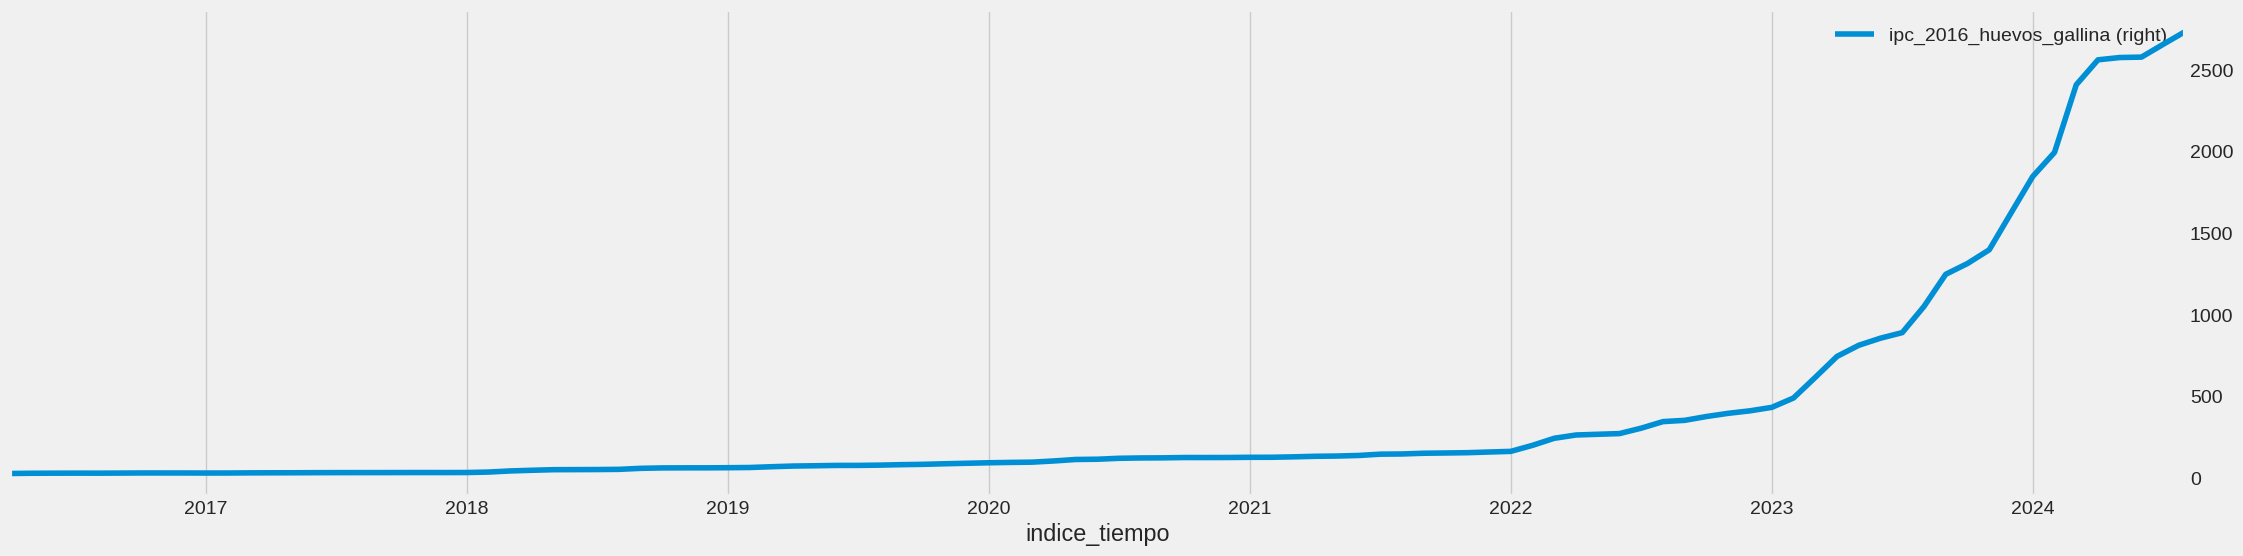

In [8]:
huevo.plot(secondary_y="ipc_2016_huevos_gallina")

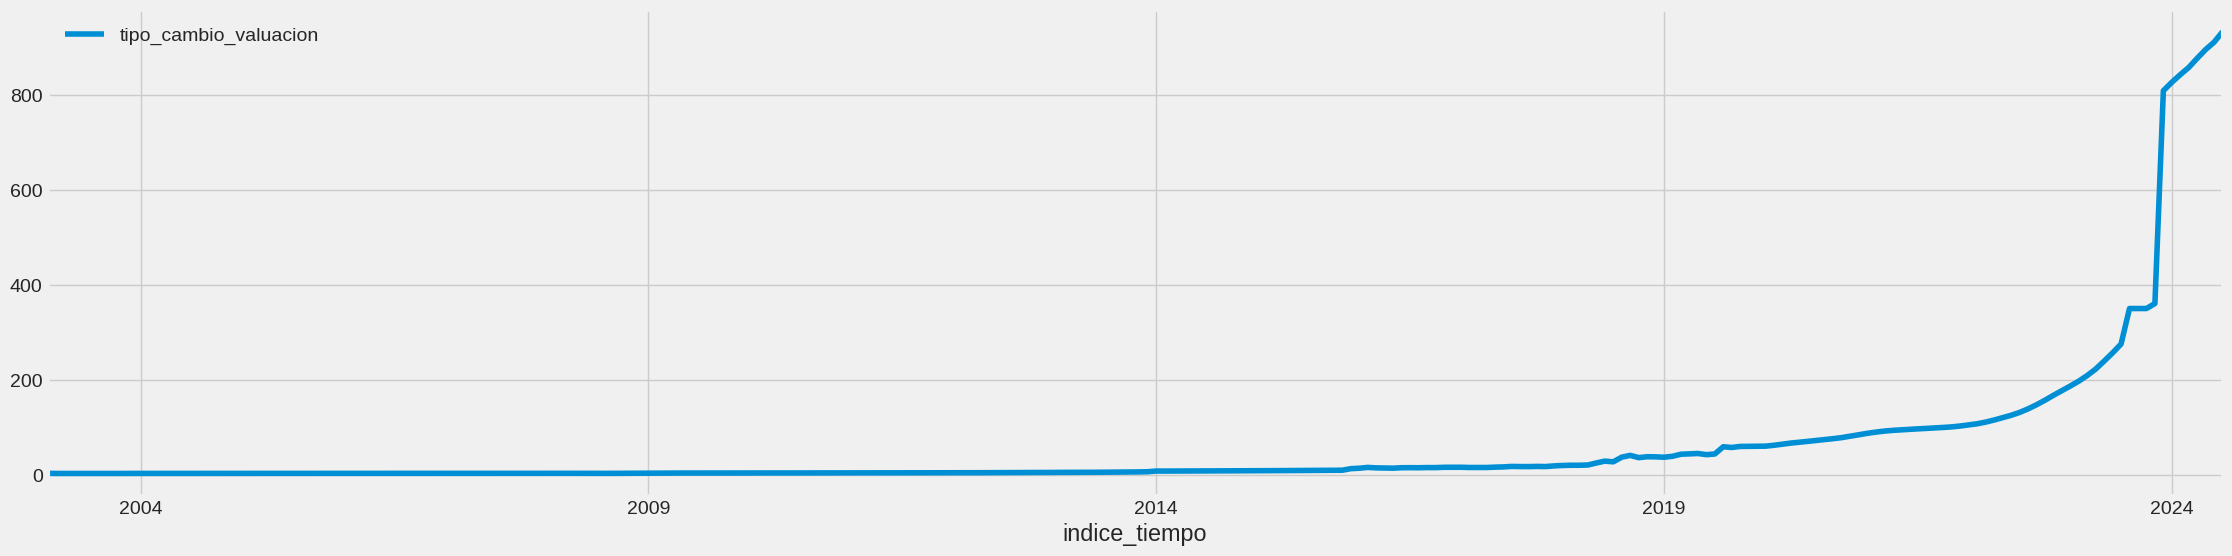

In [9]:
tdc = sdt_get('92.2_TIPO_CAMBIION_0_0_21_24',collapse='month',collapse_aggregation='end_of_period')
tdc.plot();

In [10]:
tdc.head()

,tipo_cambio_valuacion
indice_tiempo,
2003-02-01,3.1817
2003-03-01,2.8710
2003-04-01,2.8547
2003-05-01,2.8825
2003-06-01,2.7940


In [11]:
tdc.index.unique()

DatetimeIndex(['2003-02-01', '2003-03-01', '2003-04-01', '2003-05-01',
               '2003-06-01', '2003-07-01', '2003-08-01', '2003-09-01',
               '2003-10-01', '2003-11-01',
               ...
               '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01',
               '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01',
               '2024-06-01', '2024-07-01'],
              dtype='datetime64[ns]', name='indice_tiempo', length=258, freq=None)

In [12]:
# unimos los 2 dataframes:
df = huevo.merge(tdc,how='left',left_index=True, right_index=True)
# creamos/asignamos la variable huevo_duro al cociente entre el precio nominal del huevo de gallina y al tipo de cambio peso/dolar promedio mensual
df['huevo_duro'] = [np.round(h/t,2) for h,t in zip(df.ipc_2016_huevos_gallina,df.tipo_cambio_valuacion)]
df.head()

,ipc_2016_huevos_gallina,tipo_cambio_valuacion,huevo_duro
indice_tiempo,,,
2016-04-01,28.24,14.2582,1.98
2016-05-01,29.68,14.0127,2.12
2016-06-01,30.16,14.9200,2.02
2016-07-01,30.43,15.0447,2.02
2016-08-01,30.25,14.9008,2.03


<Axes: xlabel='indice_tiempo'>

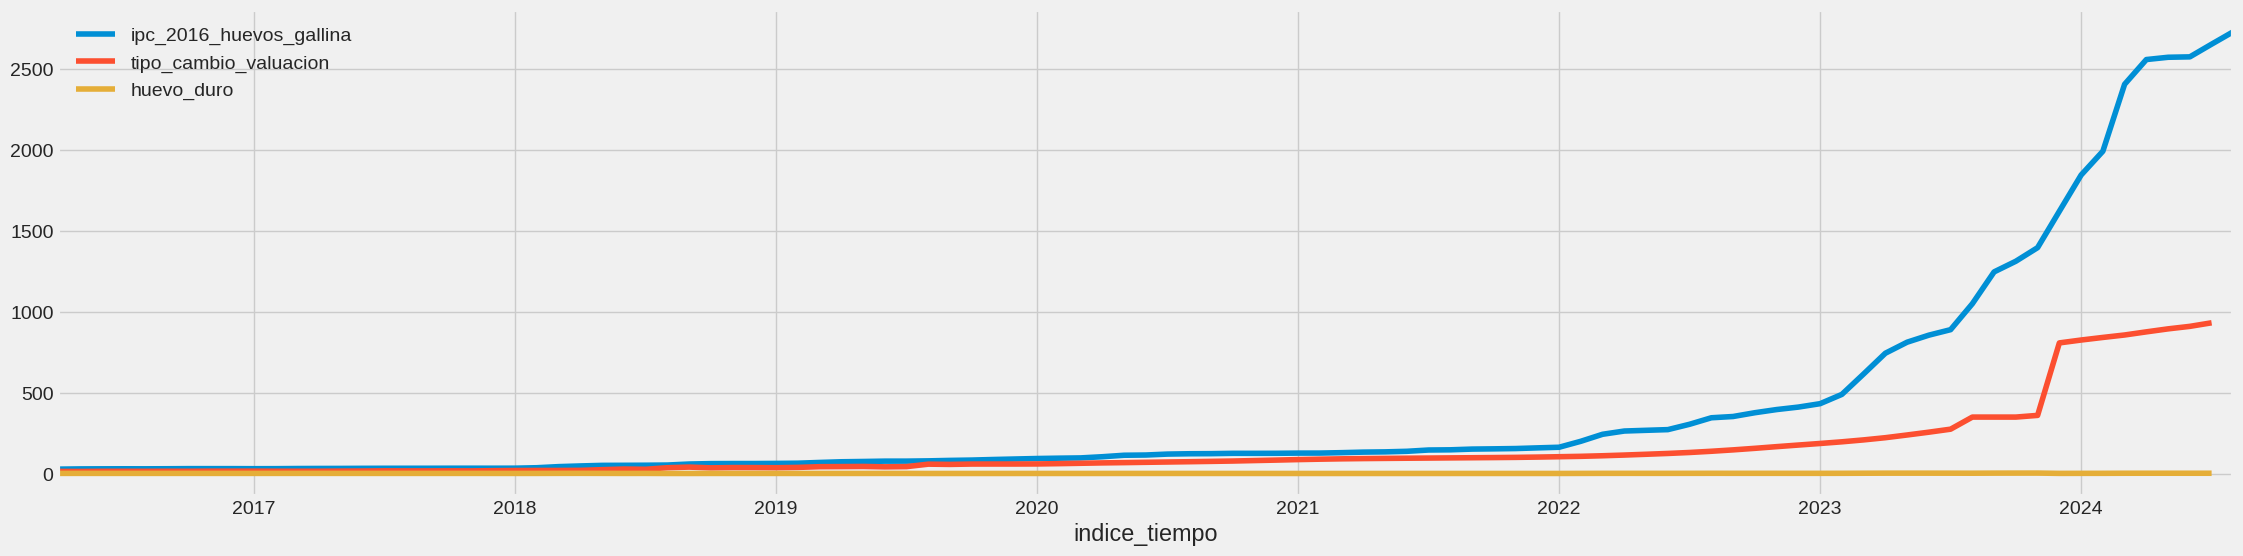

In [13]:
df.plot()

Otra forma de obtener las dos series:

<Axes: xlabel='indice_tiempo'>

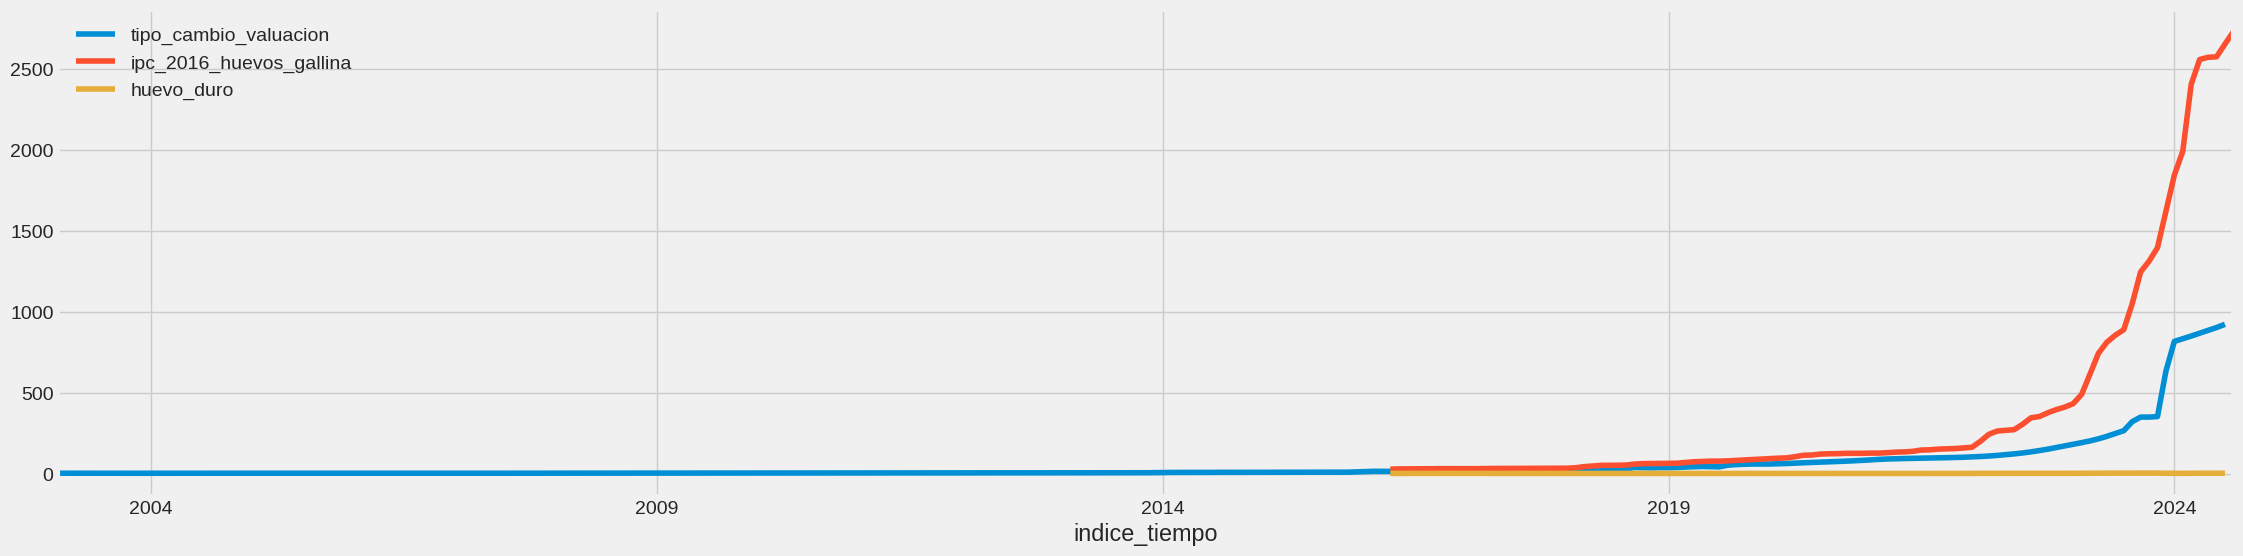

In [14]:
df2 = sdt_get(['92.2_TIPO_CAMBIION_0_0_21_24','105.1_I2HG_2016_M_23'])
df2['huevo_duro'] = [np.round(h/t,2) for h,t in zip(df2.ipc_2016_huevos_gallina,df2.tipo_cambio_valuacion)]
df2.plot()

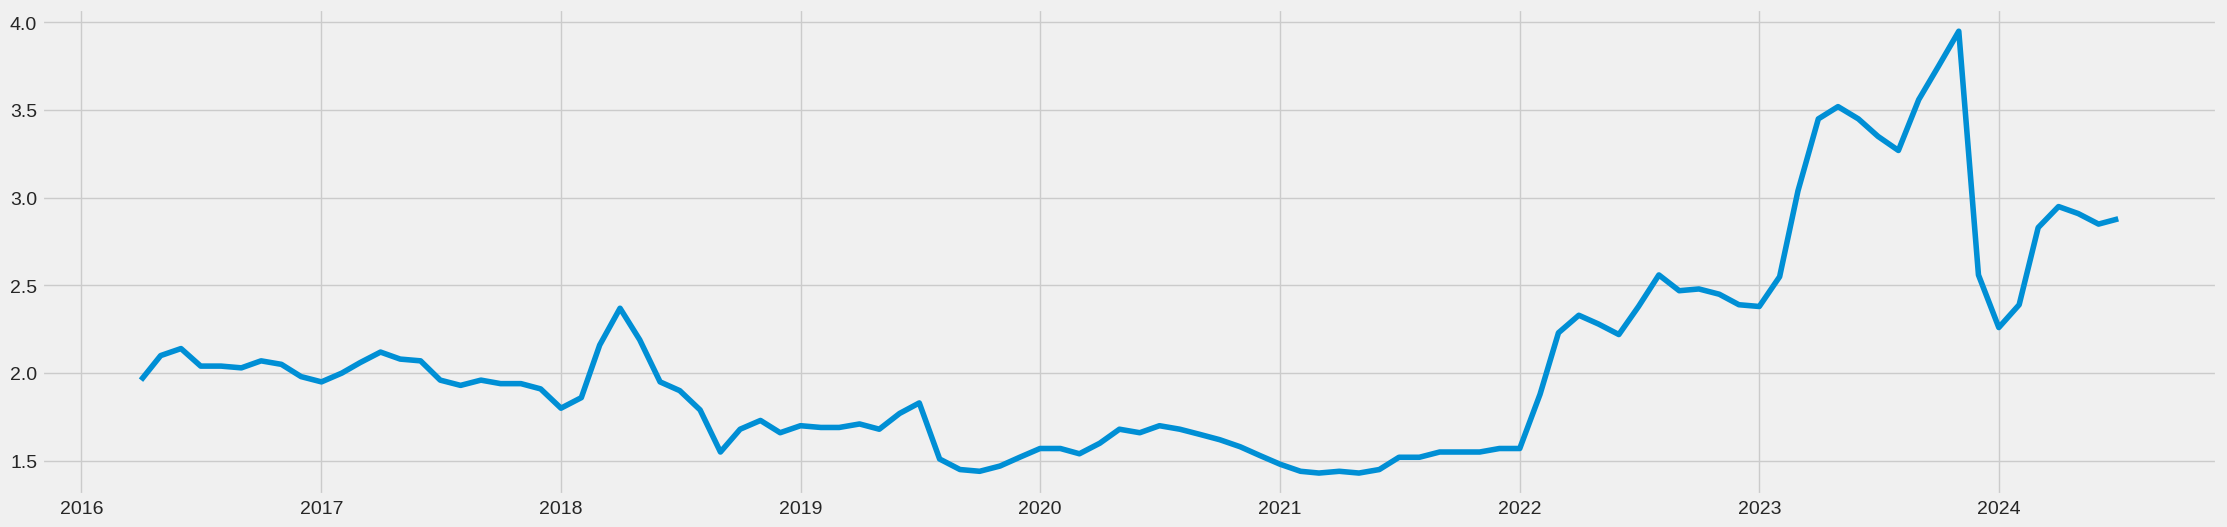

In [15]:
plt.plot(df2.huevo_duro)

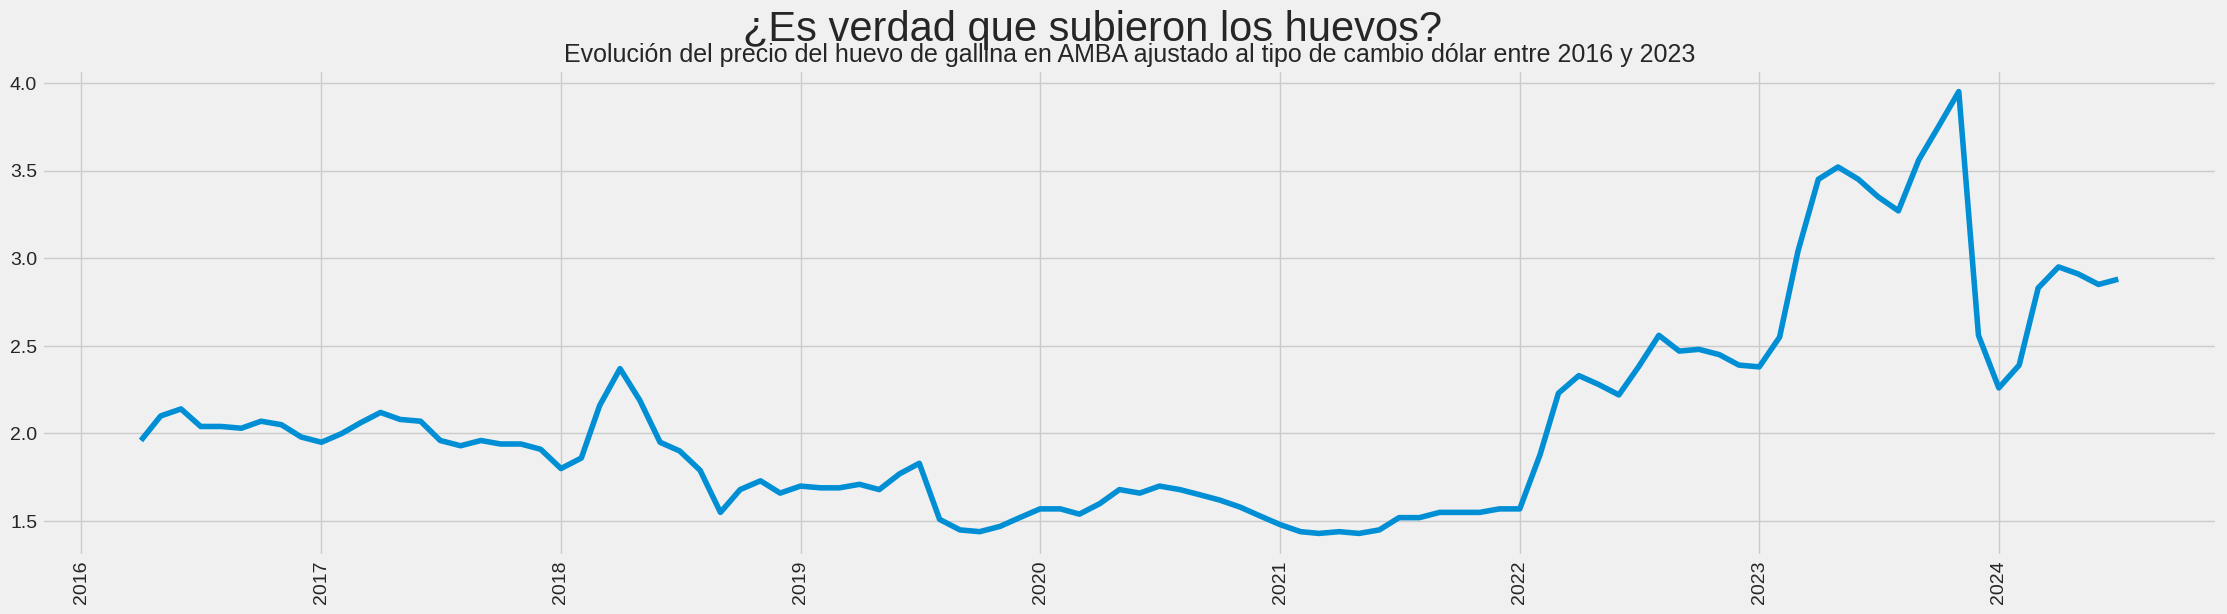

In [16]:
plt.plot(df2.huevo_duro)
plt.suptitle('¿Es verdad que subieron los huevos?',size=30)
plt.title('Evolución del precio del huevo de gallina en AMBA ajustado al tipo de cambio dólar entre 2016 y 2023',size=18,loc='center')
plt.xticks(rotation=90);

# **1. FUENTES SERIES APIs**

In [23]:
import pandas as pd
import requests
from io import StringIO

url = 'https://apis.datos.gob.ar/series/api/dump/series-tiempo-metadatos.csv'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36'
}

# Fetch the content using requests
response = requests.get(url, headers=headers)

# Check if the request was successful
if response.status_code == 200:
    # Convert the content to a StringIO object for pandas
    data = StringIO(response.text)
    fuentes = pd.read_csv(data)
    fuentes.head()
else:
    print(f"Failed to fetch data: {response.status_code} - {response.reason}")


<ipython-input-23-302c021bc762>:17: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  fuentes = pd.read_csv(data)


In [ ]:
sorted(fuentes.catalogo_id.unique())

['agroindustria',
 'bcra',
 'cultura',
 'defensa',
 'energia',
 'justicia',
 'modernizacion',
 'obras',
 'otros',
 'salud',
 'seguridad',
 'siep',
 'smn',
 'sspm',
 'test_node',
 'transporte',
 'turismo',
 'vacunas-covid']

In [ ]:
pd.DataFrame(fuentes.groupby('catalogo_id').count().iloc[:,0].sort_values(ascending=False))

,dataset_id
catalogo_id,
sspm,20208
vacunas-covid,6977
seguridad,3724
obras,1760
bcra,1550
turismo,1267
siep,1148
modernizacion,719
justicia,575


In [ ]:
pd.DataFrame(fuentes[fuentes['catalogo_id']=='bcra'].groupby('serie_descripcion').count().iloc[:,0].sort_values(ascending=False))

,catalogo_id
serie_descripcion,
Tipo de cambio de referencia diario.,2
"Agregados monetarios, saldos afin de mes, en miles de pesos - Base monetaria (M0) - Circulación monetaria - En entidades financieras",1
"Otras informaciones sobre la actividad financiera - Cuadro de resultados - Resultados mensuales, en miles de pesos - Resultados netos - Por inversiones - Total",1
"Otras informaciones sobre la actividad financiera - Cuadro de resultados - Resultados mensuales, en miles de pesos - Resultados netos - Por inversiones - En participaciones societarias",1
"Otras informaciones sobre la actividad financiera - Cuadro de resultados - Resultados mensuales, en miles de pesos - Resultados netos - Por inversiones - En obligaciones negociables",1
...,...
"Balance consolidado de las entidades financieras, en miles de pesos - Total de activos financieros disponibles y préstamos - En moneda nacional, saldos diarios, en miles de pesos - Préstamos - De efectivo - Documentos a sola firma",1
"Balance consolidado de las entidades financieras, en miles de pesos - Total de activos financieros disponibles y préstamos - En moneda nacional, saldos diarios, en miles de pesos - Préstamos - De efectivo - Créditos documentarios",1
"Balance consolidado de las entidades financieras, en miles de pesos - Total de activos financieros disponibles y préstamos - En moneda nacional, saldos diarios, en miles de pesos - Préstamos - De efectivo - Adelantos en cuenta corriente",1


In [ ]:
fuentes[(fuentes['catalogo_id']=='sspm')&(fuentes['serie_titulo']=='pesca')]

,catalogo_id,dataset_id,distribucion_id,serie_id,indice_tiempo_frecuencia,serie_titulo,serie_unidades,serie_descripcion,distribucion_titulo,distribucion_descripcion,...,serie_dias_no_cubiertos,serie_actualizada,serie_valor_ultimo,serie_valor_anterior,serie_var_pct_anterior,serie_discontinuada,consultas_total,consultas_30_dias,consultas_90_dias,consultas_180_dias
11282,sspm,11,11.1,11.1_VIPAA_2004_A_5,R/P1Y,pesca,Índice 2004=100,EMAE. Pesca,EMAE apertura por sectores. Índice Base 2004. ...,Subsecretaría de Programación Macroeconómica,...,241.0,True,154.738973,128.300000,0.206071,False,562.0,0.0,0.0,89.0
11298,sspm,11,11.2,11.2_VIPAA_2004_T_5,R/P3M,pesca,Índice 2004=100,EMAE. Pesca,EMAE apertura por sectores. Índice Base 2004. ...,Subsecretaría de Programación Macroeconómica,...,60.0,True,195.700000,112.400000,0.741103,False,433.0,0.0,0.0,81.0
11314,sspm,11,11.3,11.3_VIPAA_2004_M_5,R/P1M,pesca,Índice 2004=100,EMAE. Pesca,EMAE apertura por sectores. Índice Base 2004. ...,Subsecretaría de Programación Macroeconómica,...,60.0,True,202.000000,171.900000,0.175102,False,76890.0,0.0,0.0,413.0
15516,sspm,22,22.1,22.1_P_1993_A_5,R/P1Y,pesca,Índice 1993=100,Índice de precios implícitos a precios de prod...,Índice de precios implícitos del Valor Agregad...,Subsecretaría de Programación Macroeconómica,...,3528.0,False,592.284727,523.184963,0.132075,False,417.0,0.0,0.0,57.0
15537,sspm,22,22.2,22.2_P_1993_T_5,R/P3M,pesca,Índice 1993=100,Índice de precios implícitos a precios de prod...,Índice de precios implícitos del Valor Agregad...,Subsecretaría de Programación Macroeconómica,...,3255.0,False,1284.369717,1490.451733,-0.138268,False,349.0,0.0,0.0,39.0
15560,sspm,23,23.1,23.1_P_2004_A_5,R/P1Y,pesca,Índice 2004=100,Índice de precios implícitos de pesca,Índice de precios implícitos del Valor Agregad...,Subsecretaría de Programación Macroeconómica,...,241.0,True,6452.388407,4496.963493,0.434832,False,289.0,0.0,0.0,32.0
15583,sspm,23,23.2,23.2_P_2004_T_5,R/P3M,pesca,Índice 2004=100,Índice de precios implícitos de pesca,Índice de precios implícitos del Valor Agregad...,Subsecretaría de Programación Macroeconómica,...,151.0,True,6372.633356,7025.769449,-0.092963,False,330.0,0.0,0.0,34.0
16336,sspm,305,305.1,305.1_PESCASCA_0_5,R/P1Y,pesca,Millones de pesos corrientes,Pesca,VAP - Valor Agregado Bruto a precios básicos p...,Subsecretaría de Programación Macroeconómica,...,241.0,True,144023.752607,86128.142883,0.672203,False,282.0,0.0,0.0,38.0
16404,sspm,305,305.2,305.2_PESCASCA_0_5,R/P3M,pesca,Millones de pesos corrientes,Pesca,VAP - Valor Agregado Bruto a precios básicos p...,Subsecretaría de Programación Macroeconómica,...,151.0,True,103333.091605,87806.145318,0.176832,False,246.0,0.0,0.0,26.0
16463,sspm,305,305.3,306.1_PESCASCA_0_A_5,R/P1Y,pesca,2004=100,Índice de Precios Implícitos del Valor Agregad...,Índice de Precios Implícitos del Valor Agregad...,Subsecretaría de Programación Macroeconómica,...,241.0,True,6452.388407,4496.963493,0.434832,False,221.0,0.0,0.0,19.0


In [ ]:
pd.DataFrame(fuentes[fuentes['catalogo_id']=='sspm'].groupby('serie_titulo').count().iloc[:,0].sort_values(ascending=False))[0:50]

,catalogo_id
serie_titulo,
construccion,49
explotacion_minas_canteras,40
comercio_mayorista_minorista_reparaciones,38
pesca,35
erog_corr_total_erog_corr,32
ahorro,32
resultado,32
total_rec_desp_figur,32
aum_pas_fin_netos,32


In [ ]:
fuentes[fuentes['catalogo_id']=='distribucion_descripcion'].head()

,catalogo_id,dataset_id,distribucion_id,serie_id,indice_tiempo_frecuencia,serie_titulo,serie_unidades,serie_descripcion,distribucion_titulo,distribucion_descripcion,...,serie_dias_no_cubiertos,serie_actualizada,serie_valor_ultimo,serie_valor_anterior,serie_var_pct_anterior,serie_discontinuada,consultas_total,consultas_30_dias,consultas_90_dias,consultas_180_dias


In [ ]:
fuentes[fuentes['catalogo_id']=='siep'].head()

,catalogo_id,dataset_id,distribucion_id,serie_id,indice_tiempo_frecuencia,serie_titulo,serie_unidades,serie_descripcion,distribucion_titulo,distribucion_descripcion,...,serie_dias_no_cubiertos,serie_actualizada,serie_valor_ultimo,serie_valor_anterior,serie_var_pct_anterior,serie_discontinuada,consultas_total,consultas_30_dias,consultas_90_dias,consultas_180_dias
9012,siep,1,1.1,tcrse_2weZeH,R/P1M,151_produccion_y_procesamiento_de_alimentos,Índice - Base Noviembre 2015=100,Índice de Tipo de Cambio Real Sectorial Efecti...,Índice de Tipo de Cambio Real Sectorial Efecti...,Ministerio de Producción. Secretaría de Transf...,...,1036.0,False,164.9,157.1,0.049650,False,13058.0,11.0,67.0,168.0
9013,siep,1,1.1,tcrse_49xDd3,R/P1M,222_actividades_de_impresion,Índice - Base Noviembre 2015=100,Índice de Tipo de Cambio Real Sectorial Efecti...,Índice de Tipo de Cambio Real Sectorial Efecti...,Ministerio de Producción. Secretaría de Transf...,...,1036.0,False,157.9,157.9,0.000000,False,10659.0,9.0,41.0,116.0
9014,siep,1,1.1,tcrse_4sgTaJ,R/P1M,191_productos_del_cuero,Índice - Base Noviembre 2015=100,Índice de Tipo de Cambio Real Sectorial Efecti...,Índice de Tipo de Cambio Real Sectorial Efecti...,Ministerio de Producción. Secretaría de Transf...,...,1036.0,False,158.1,154.3,0.024627,False,10643.0,8.0,41.0,107.0
9015,siep,1,1.1,tcrse_78ofi1,R/P1M,111_extraccion_de_petroleo_crudo_y_gas_natural,Índice - Base Noviembre 2015=100,Índice de Tipo de Cambio Real Sectorial Efecti...,Índice de Tipo de Cambio Real Sectorial Efecti...,Ministerio de Producción. Secretaría de Transf...,...,1036.0,False,157.4,156.4,0.006394,False,10688.0,11.0,44.0,129.0
9016,siep,1,1.1,tcrse_7bZNfw,R/P1M,242_otros_productos_quimicos,Índice - Base Noviembre 2015=100,Índice de Tipo de Cambio Real Sectorial Efecti...,Índice de Tipo de Cambio Real Sectorial Efecti...,Ministerio de Producción. Secretaría de Transf...,...,1036.0,False,157.5,156.4,0.007033,False,10512.0,7.0,37.0,99.0


In [ ]:
# list(fuentes[fuentes['catalogo_id']=='bcra']['serie_descripcion'])

In [ ]:
len(list(fuentes[fuentes['catalogo_id']=='smn']['serie_id']))

240

# **2. CASO ACTIVIDAD ECONOMICA I**

In [17]:
df = sdt_get(['143.3_NO_PR_2004_A_31','143.3_NO_PR_2004_A_28','143.3_NO_PR_2004_A_21'])

df.head()

,emae_desestacionalizada,emae_tendencia_ciclo,emae_original
indice_tiempo,,,
2004-01-01,98.418870,96.058679,92.627506
2004-02-01,98.166845,96.656444,90.186179
2004-03-01,97.809218,97.324076,101.883298
2004-04-01,95.060927,98.019660,102.567430
2004-05-01,96.889738,98.741689,109.877504


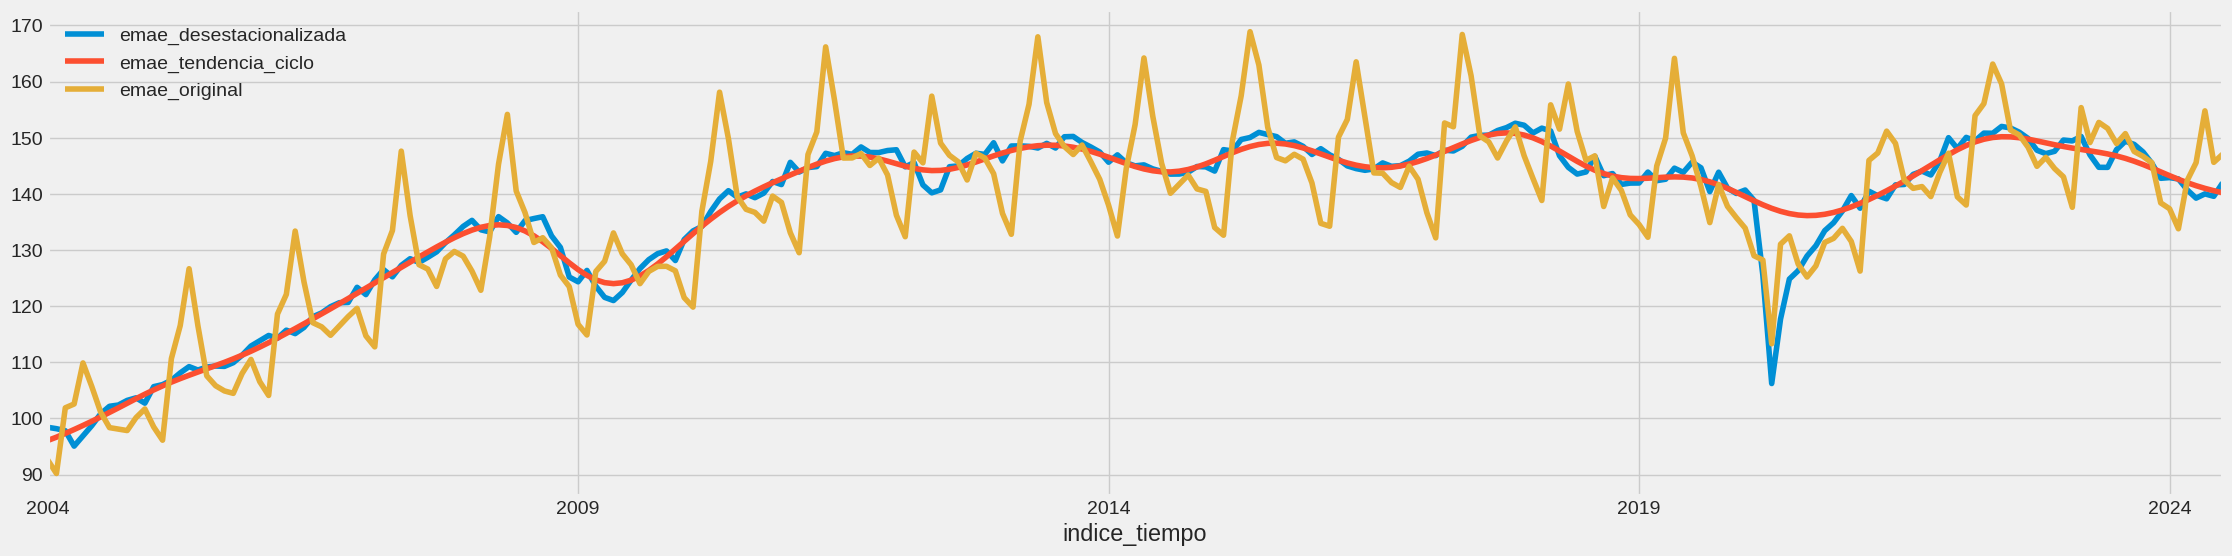

In [18]:
df.plot();

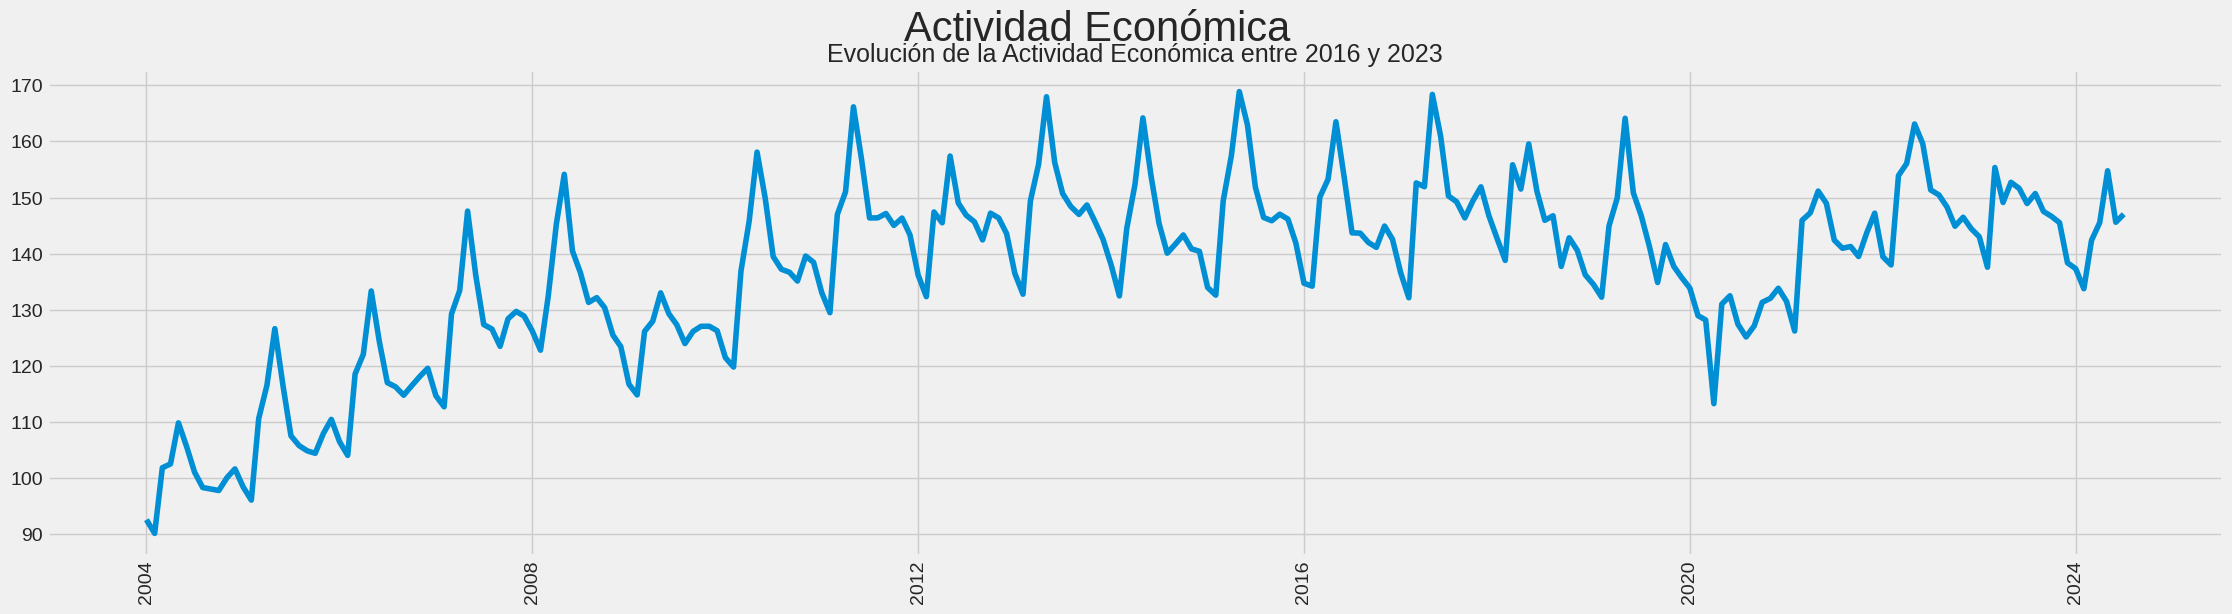

In [19]:
plt.plot(df.emae_original)
plt.suptitle('Actividad Económica',size=30)
plt.title('Evolución de la Actividad Económica entre 2016 y 2023',size=18,loc='center')
plt.xticks(rotation=90);

# **3. CASO ACTIVIDAD ECONOMICA II**

In [20]:
df = sdt_get(['143.3_NO_PR_2004_A_31','143.3_NO_PR_2004_A_28','143.3_NO_PR_2004_A_21'],representation_mode='change')
df.head()

,emae_desestacionalizada_var_var_var,emae_tendencia_ciclo,emae_original
indice_tiempo,,,
2004-02-01,-0.252025,0.597765,-2.441327
2004-03-01,-0.357627,0.667632,11.697119
2004-04-01,-2.748291,0.695585,0.684132
2004-05-01,1.828811,0.722029,7.310074
2004-06-01,1.828353,0.746949,-4.215098


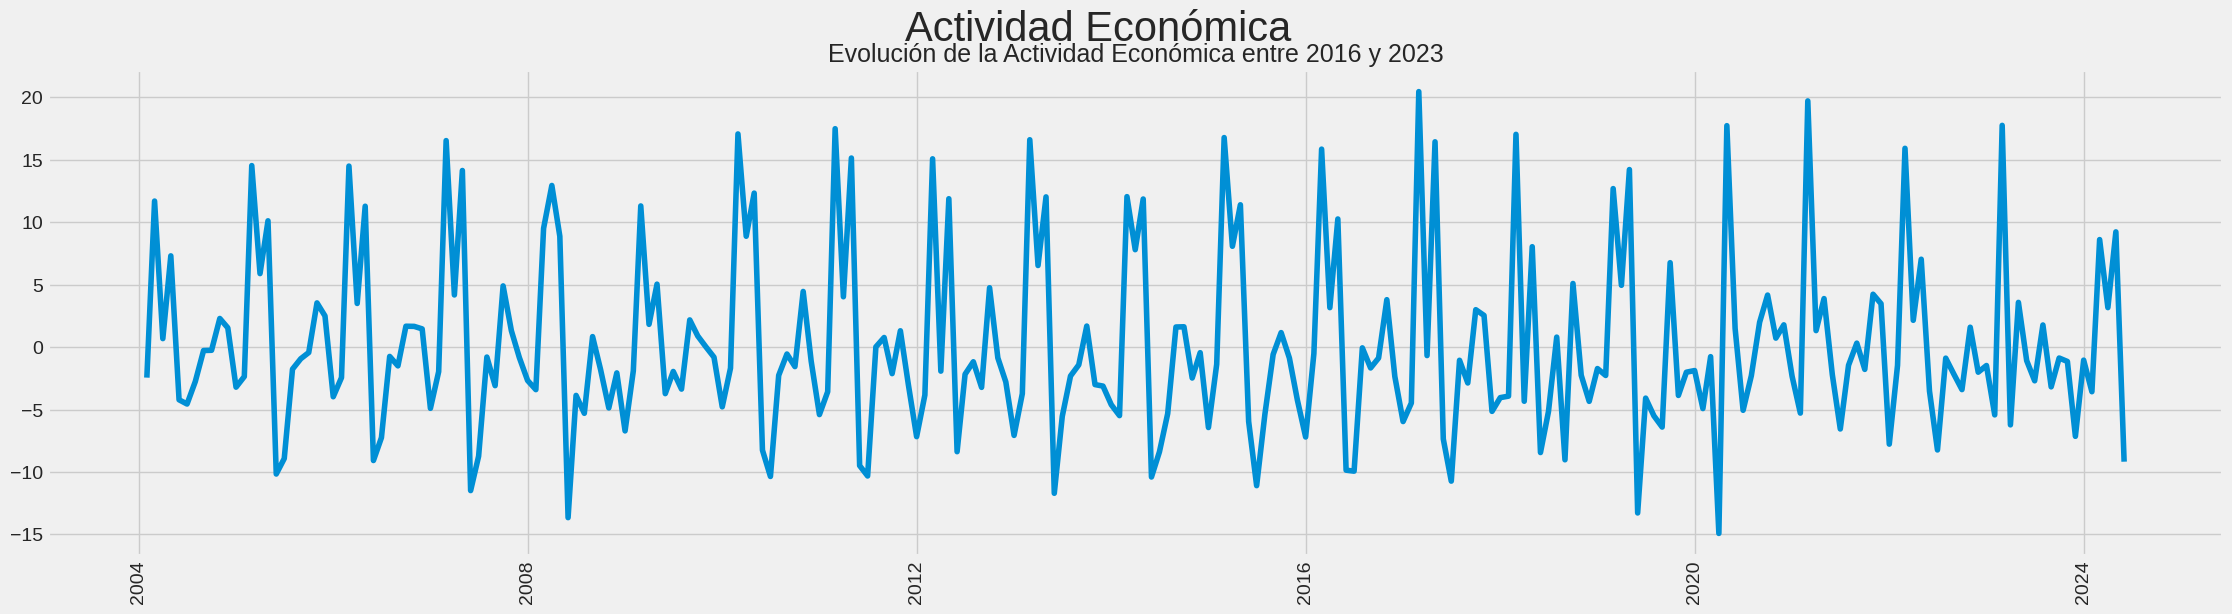

In [21]:
plt.plot(df.emae_original)
plt.suptitle('Actividad Económica',size=30)
plt.title('Evolución de la Actividad Económica entre 2016 y 2023',size=18,loc='center')
plt.xticks(rotation=90);

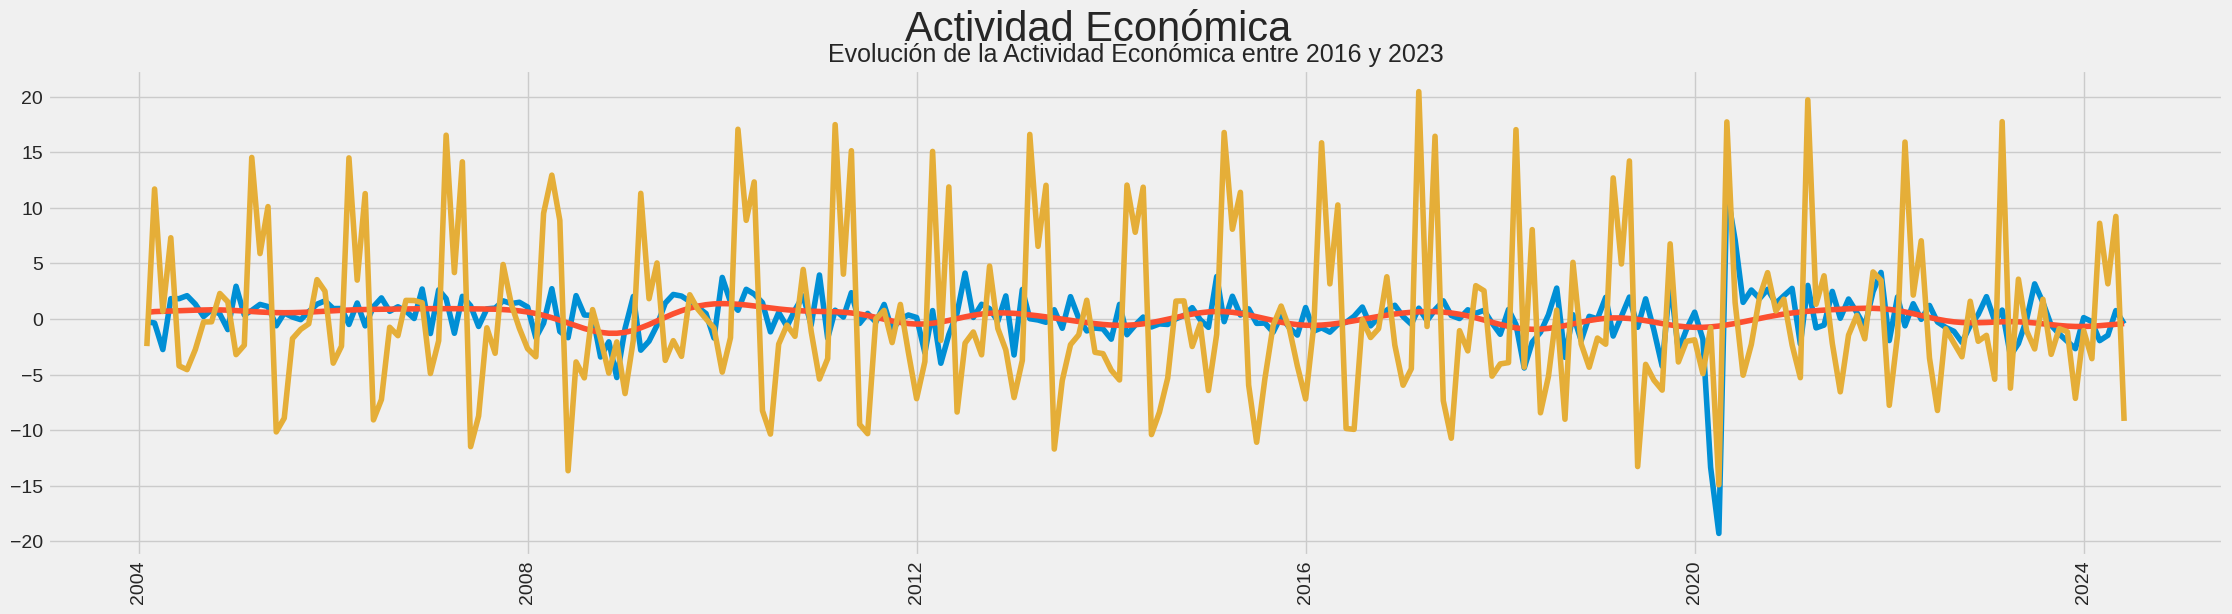

In [22]:
plt.plot(df)
plt.suptitle('Actividad Económica',size=30)
plt.title('Evolución de la Actividad Económica entre 2016 y 2023',size=18,loc='center')
plt.xticks(rotation=90);

# **4. CASO ACTIVIDAD ECONOMICA III**

In [ ]:
df = sdt_get('143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41')
df.head()

143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41&


,emae_original,construccion,industria_manufacturera,pesca,agricultura_ganaderia_caza_silvicultura,hoteles_restaurantes,comercio_mayorista_minorista_reparaciones
indice_tiempo,,,,,,,
2004-01-01,92.627506,95.938047,91.454610,42.547868,65.995350,108.411682,92.065338
2004-02-01,90.186179,98.853388,89.424852,62.440771,64.926598,103.448256,91.464718
2004-03-01,101.883298,103.124529,101.426433,174.084646,110.666559,101.061842,109.127780
2004-04-01,102.567430,95.815492,98.437312,153.877638,150.065920,93.242999,99.420141
2004-05-01,109.877504,97.994567,100.353138,132.357664,209.388076,90.985260,100.532744


In [ ]:
corr = df.corr().round(2)
corr

,emae_original,construccion,industria_manufacturera,pesca,agricultura_ganaderia_caza_silvicultura,hoteles_restaurantes,comercio_mayorista_minorista_reparaciones
emae_original,1.00,0.71,0.76,0.41,0.46,0.48,0.89
construccion,0.71,1.00,0.76,0.25,-0.06,0.71,0.80
industria_manufacturera,0.76,0.76,1.00,0.32,0.10,0.50,0.90
pesca,0.41,0.25,0.32,1.00,0.25,0.07,0.36
agricultura_ganaderia_caza_silvicultura,0.46,-0.06,0.10,0.25,1.00,-0.22,0.14
hoteles_restaurantes,0.48,0.71,0.50,0.07,-0.22,1.00,0.51
comercio_mayorista_minorista_reparaciones,0.89,0.80,0.90,0.36,0.14,0.51,1.00


<AxesSubplot:>

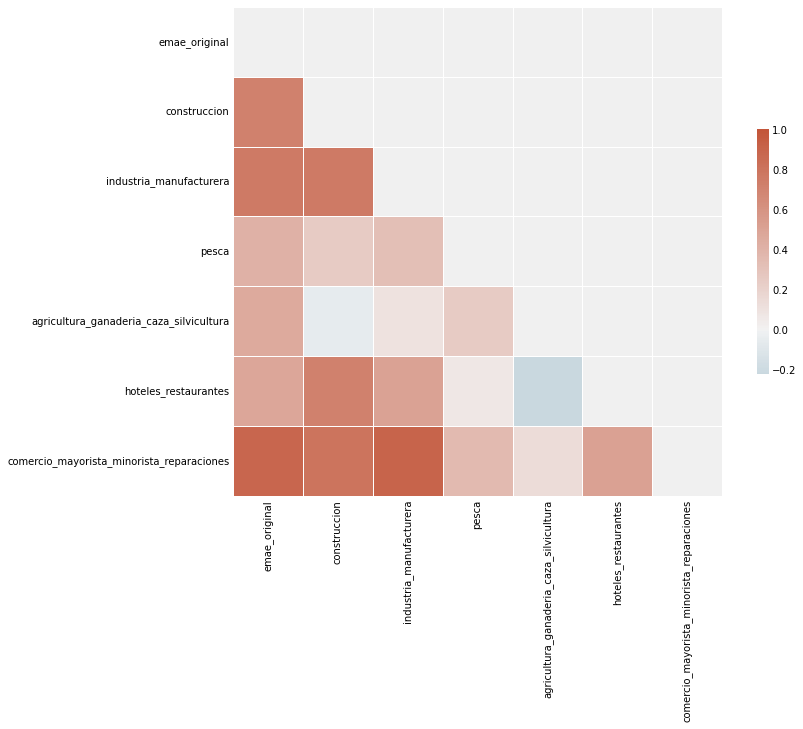

In [ ]:
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

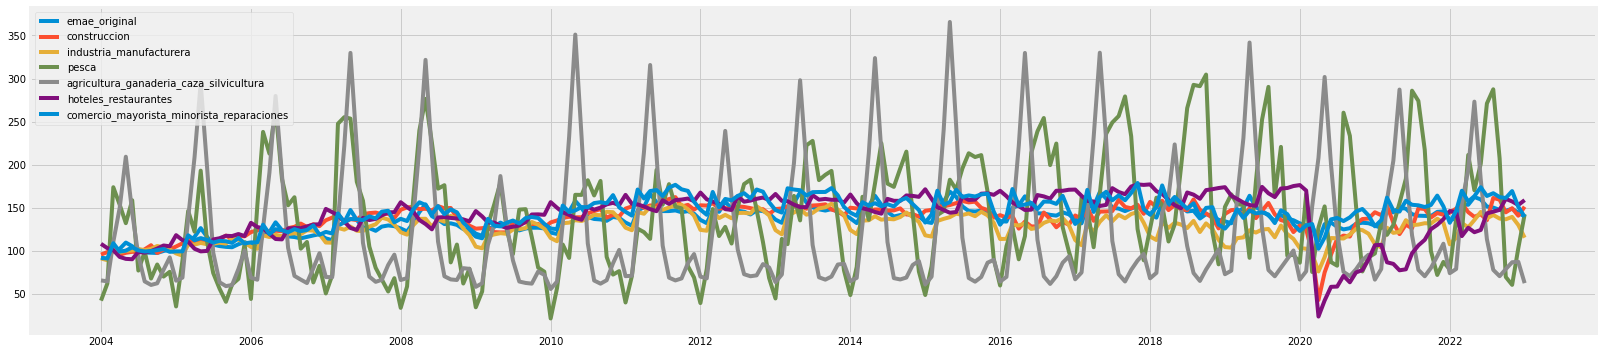

In [ ]:
plt.plot(df);
plt.legend(df.columns,loc='upper left');

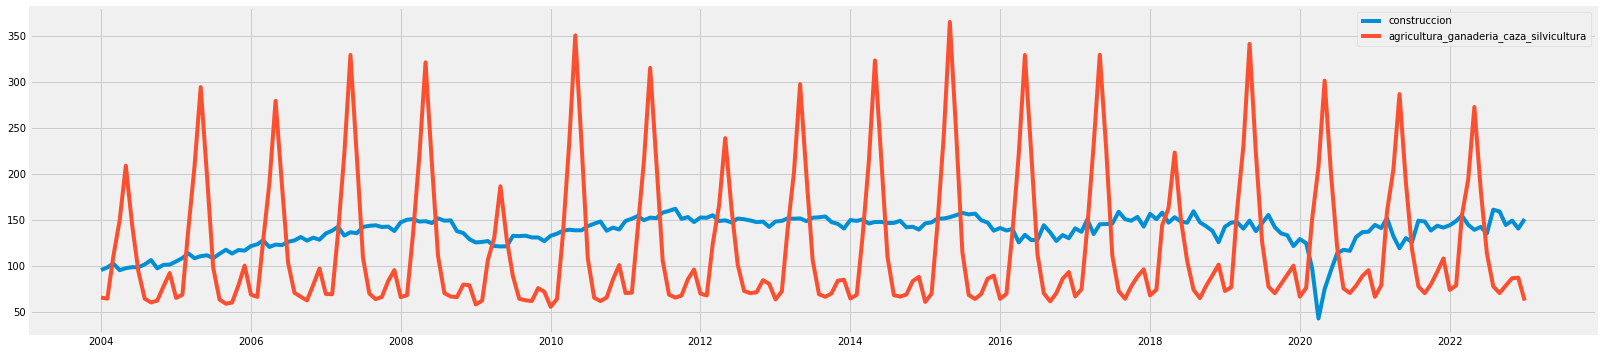

In [ ]:
plt.plot(df[['construccion','agricultura_ganaderia_caza_silvicultura']])
plt.legend(['construccion','agricultura_ganaderia_caza_silvicultura']);

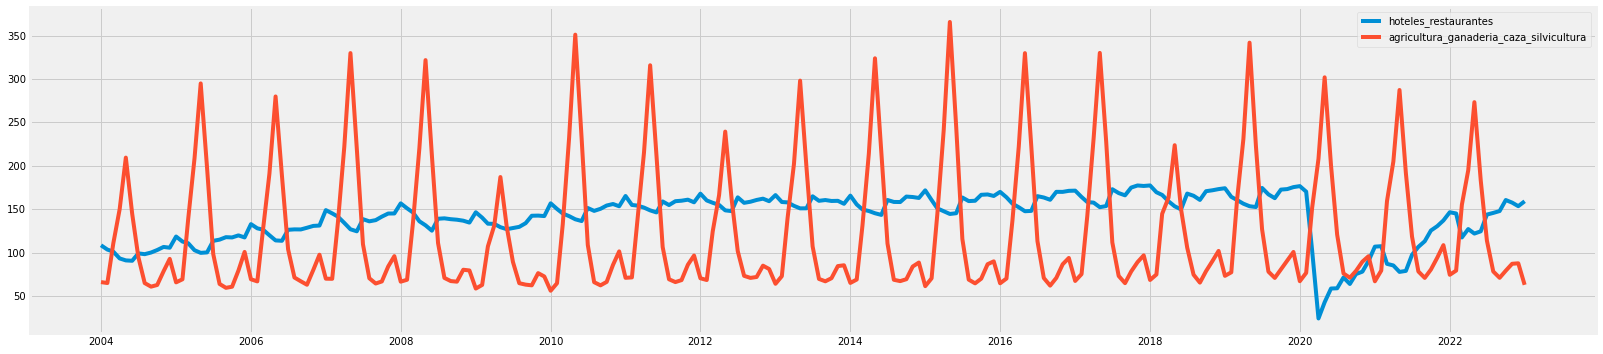

In [ ]:
plt.plot(df[['hoteles_restaurantes','agricultura_ganaderia_caza_silvicultura']])
plt.legend(['hoteles_restaurantes','agricultura_ganaderia_caza_silvicultura']);

# **4. CASO ACTIVIDAD ECONOMICA IV**

143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41&representation_mode=change&


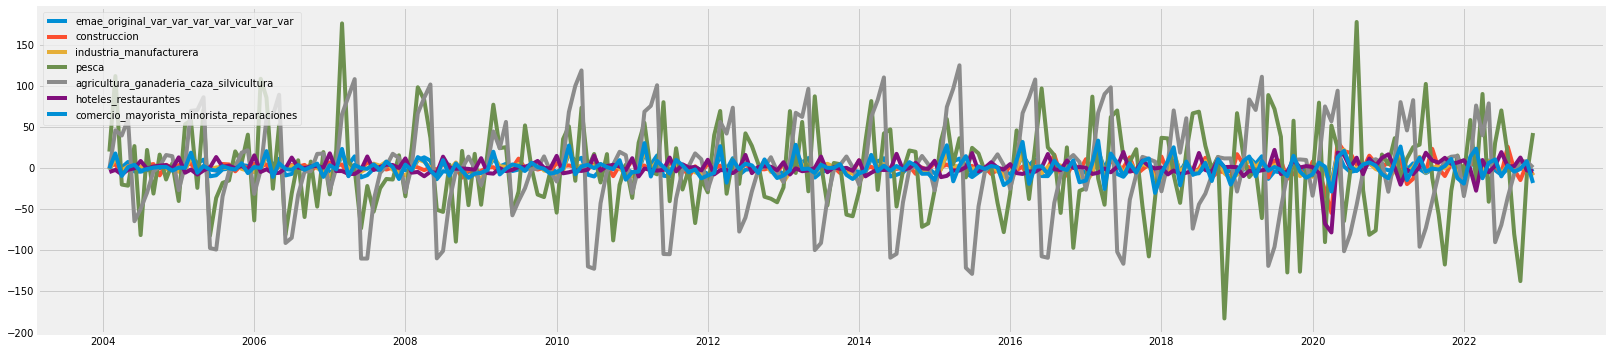

In [ ]:
df = sdt_get('143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41',representation_mode='change')
plt.plot(df);
plt.legend(df.columns,loc='upper left');

# **4. CASO TIPO DE CAMBIO**

In [ ]:
tipo_de_cambio ='tc_usd_bna_ev15'
df = sdt_get([tipo_de_cambio+':avg',tipo_de_cambio+':min',tipo_de_cambio+':max'],collapse='month')
df.columns = ['tdc_avg','tdc_min','tdc_max']
df.head()

tc_usd_bna_ev15:avg,tc_usd_bna_ev15:min,tc_usd_bna_ev15:max&collapse=month&


,tdc_avg,tdc_min,tdc_max
indice_tiempo,,,
2017-03-01,15.713636,15.55,15.80
2017-04-01,15.533333,15.40,15.70
2017-05-01,15.908571,15.50,16.38
2017-06-01,16.311905,16.05,16.80
2017-07-01,17.394000,17.00,17.96


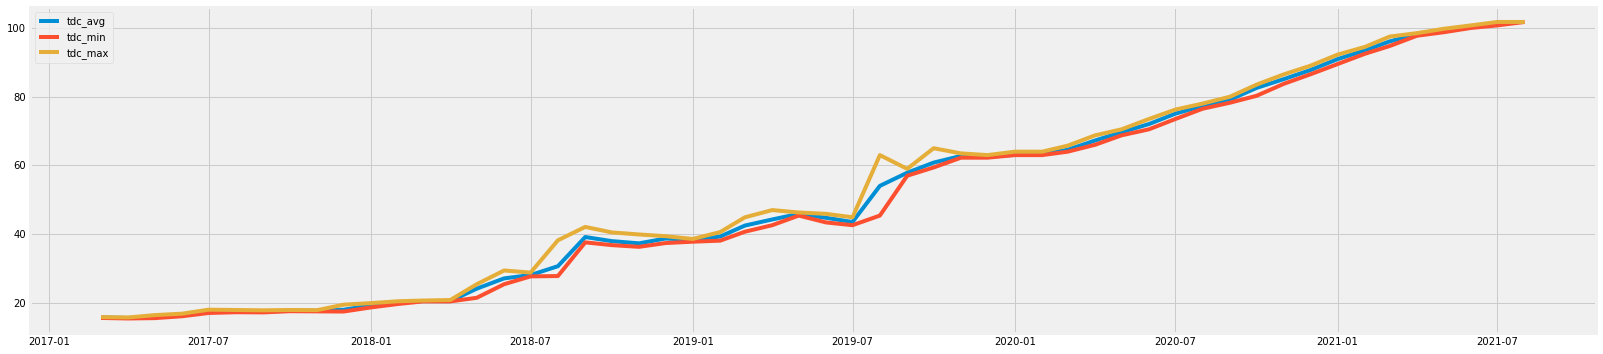

In [ ]:
plt.plot(df);
plt.legend(df.columns,loc='upper left');

tc_usd_bna_ev15:avg,tc_usd_bna_ev15:min,tc_usd_bna_ev15:max&collapse=month&representation_mode=change&


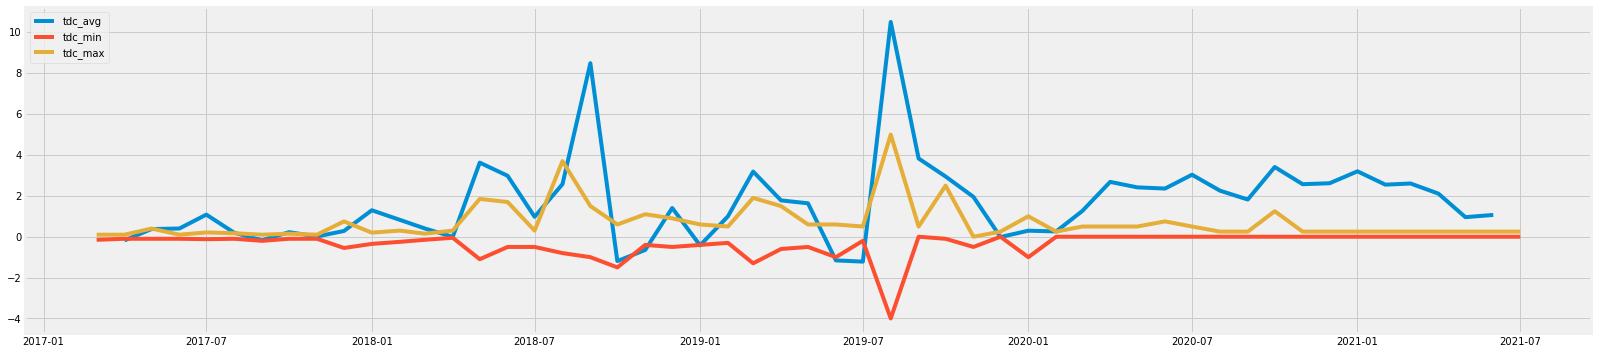

In [ ]:
tipo_de_cambio ='tc_usd_bna_ev15'
df = sdt_get([tipo_de_cambio+':avg',tipo_de_cambio+':min',tipo_de_cambio+':max'],collapse='month',representation_mode='change')
df.columns = ['tdc_avg','tdc_min','tdc_max']
plt.plot(df);
plt.legend(df.columns,loc='upper left');